In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [52]:
DATA_PATH = '../Others/Data/Advertising.csv'

In [53]:
dataset = pd.read_csv(DATA_PATH)
dataset.head(10)

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9
5,6,8.7,48.9,75.0,7.2
6,7,57.5,32.8,23.5,11.8
7,8,120.2,19.6,11.6,13.2
8,9,8.6,2.1,1.0,4.8
9,10,199.8,2.6,21.2,10.6


In [54]:
dataset = dataset.drop(columns=['Unnamed: 0'], axis=1)
X = dataset.iloc[:, :-1]
print(X)
y = dataset.iloc[:, -1]
print(y)

        TV  Radio  Newspaper
0    230.1   37.8       69.2
1     44.5   39.3       45.1
2     17.2   45.9       69.3
3    151.5   41.3       58.5
4    180.8   10.8       58.4
5      8.7   48.9       75.0
6     57.5   32.8       23.5
7    120.2   19.6       11.6
8      8.6    2.1        1.0
9    199.8    2.6       21.2
10    66.1    5.8       24.2
11   214.7   24.0        4.0
12    23.8   35.1       65.9
13    97.5    7.6        7.2
14   204.1   32.9       46.0
15   195.4   47.7       52.9
16    67.8   36.6      114.0
17   281.4   39.6       55.8
18    69.2   20.5       18.3
19   147.3   23.9       19.1
20   218.4   27.7       53.4
21   237.4    5.1       23.5
22    13.2   15.9       49.6
23   228.3   16.9       26.2
24    62.3   12.6       18.3
25   262.9    3.5       19.5
26   142.9   29.3       12.6
27   240.1   16.7       22.9
28   248.8   27.1       22.9
29    70.6   16.0       40.8
..     ...    ...        ...
170   50.0   11.6       18.4
171  164.5   20.9       47.4
172   19.6   2

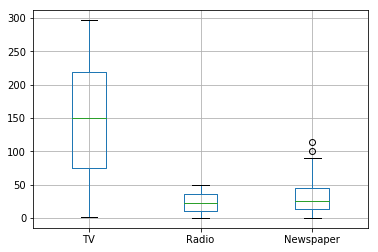

In [55]:
dataset.boxplot(column=list(X.columns))

In [56]:
X = np.c_[np.ones((X.shape[0], 1)), X]
y = np.array(y)

In [57]:
def compute_loss(individual):
    theta = np.array(individual)
    y_hat = X.dot(theta)
    loss = np.multiply((y_hat - y), (y_hat - y)).mean()
    return loss

def compute_fitness(individual):
    loss = compute_loss(individual)
    fitness = 1/(loss + 1)
    return fitness

In [58]:
# Using np.random.rand() for randomly generating a variable used for functions related to the evolution.

bound = 200

def generate_random_value():
    return (np.random.rand()-0.5)*bound

def generate_individual(n_bits):
    return[generate_random_value() for _ in range(n_bits)]

def generate_population(n_inds, n_bits):
    return [generate_individual(n_bits) for _ in range(n_inds)]


In [69]:
def crossover(individual_1, individual_2, r_cross = 0.1):
    child_1 = individual_1.copy()
    child_2 = individual_2.copy()

    for i in range(len(individual_1)):
        seed = np.random.rand()
        if seed < r_cross:
            child_1[i] = individual_2[i]
            child_2[i] = individual_1[i]
            
    return child_1, child_2


def mutate(individual, r_mutate=0.1):
    for i in range(len(individual)):
        seed = np.random.rand()
        if seed < r_mutate:
            individual[i] = generate_random_value()

def selection(sorted_population):
    rand_idx_1 = np.random.randint(0, len(sorted_population) - 1)
    rand_idx_2 = np.random.randint(0, len(sorted_population) - 1)

    # To avoid 2 rand_idx equal to each other.
    while rand_idx_1 == rand_idx_2:
        rand_idx_2 = np.random.randint(0, len(sorted_population) - 1)
    
    the_chosen_one = sorted_population[rand_idx_1]
    if rand_idx_2 > rand_idx_1:
        the_chosen_one = sorted_population[rand_idx_2]

    return the_chosen_one

In [73]:
n_bits = X.shape[1]
n_pop = 100
n_generations = 1000
losses = []

population = generate_population(n_pop, n_bits)
elitism = 2

for i in range(n_generations):
    sorted_population = sorted(population, key=compute_fitness)

    # Update los
    if i%100 == 0:
        losses.append(compute_loss(sorted_population[n_pop - 1]))

    new_population = sorted_population[:elitism]

    while len(new_population) < n_pop:
        # Select 2 individuals in the selected group.
        selected_individual_1 = selection(new_population)
        selected_individual_2 = selection(population[:elitism])

        # Crossover both of them.
        child_1, child_2 = crossover(selected_individual_1, selected_individual_2)
        
        # Mutate to create a diversity within the specie. 
        mutate_child_1 = mutate(child_1)
        mutate_child_2 = mutate(child_2)

        # Add the results to the new population. 
        new_population.append(mutate_child_1)
        new_population.append(mutate_child_2)
    
    population = new_population

KeyboardInterrupt: 